# Palmer penguins sex — init sensitivity (scaled, 75% train)

Logistic regression for sex from bill and body measurements. Covariates are **standardized on the training fold** (test covariates use the same train fit). We compare PrO particle initialization schemes `init="jitter"` vs `init="prior"` under identical sampler settings.

All `sample_pro` runs fit the **75% train split** only; the held-out 25% is used later for predictive checks (no refitting).


In [1]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from itertools import combinations
from matplotlib.colors import LinearSegmentedColormap

from palmerpenguins import load_penguins
from sklearn.preprocessing import StandardScaler

from pymc_prop import sample_pro

# --- plot styling ---
FIGSIZE = (6.5, 4.0)
COLOR_DATA = "0.6"
COLOR_PRO = "#bca0ff"
PRO_CMAP = LinearSegmentedColormap.from_list("white_to_pro", ["white", COLOR_PRO])
N_LEVELS = 6
BW_ADJUST_1D = 2.0
BW_ADJUST_2D = 0.75
PAD_2D = 0.4

INIT_CHOICES = ("jitter", "prior")
INIT_COLORS = {"jitter": COLOR_DATA, "prior": COLOR_PRO}
SEX_PALETTE = {0: COLOR_DATA, 1: "0.15"}

# --- reproducible train/test split ---
SPLIT_SEED = 42
TRAIN_FRAC = 0.75
HOLDOUT_SEED = 0  # seed used later for hold-out predictive plots/metrics

# --- PrO sampler grid (train fit) ---
SEEDS = [0, 1, 2, 3, 4]
JITTER = 0.1  # only applies when init="jitter"
N_PARTICLES = 40
N_STEPS = 1500
STEP_SIZE = 2e-3
BURN_IN = 0  # keep full particle history for trajectory plots


In [2]:
penguins = load_penguins()
cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
COL_LABELS = {
    "bill_length_mm": "bill length (mm)",
    "bill_depth_mm": "bill depth (mm)",
    "flipper_length_mm": "flipper length (mm)",
    "body_mass_g": "body mass (g)",
}

df = penguins.dropna(subset=["sex", *cols])
df = df[df["sex"].isin(["male", "female"])].copy()

# fixed permutation split: 75% train / 25% test
perm = np.random.default_rng(SPLIT_SEED).permutation(len(df))
n_train = int(np.floor(TRAIN_FRAC * len(df)))
train_idx, test_idx = perm[:n_train], perm[n_train:]

scaler = StandardScaler()
X_train = scaler.fit_transform(df[cols].values[train_idx])  # fit on train only
X_test = scaler.transform(df[cols].values[test_idx])
y_train = (df["sex"].values[train_idx] == "male").astype(int)
y_test = (df["sex"].values[test_idx] == "male").astype(int)
print(f"train n = {len(train_idx)}, test n = {len(test_idx)}")

# logistic regression in PyMC value_vars space (beta includes intercept)
with pm.Model() as model:
    beta = pm.Normal("beta", mu=0.0, sigma=1.0, shape=5)
    logit_p = beta[0] + pt.dot(X_train, beta[1:])
    pm.Bernoulli("sex", logit_p=logit_p, observed=y_train)


train n = 249, test n = 84


## Train-set init sensitivity

Run `sample_pro` on the train likelihood only. Settings: 40 particles, 1500 steps, `step_size=2e-3`, `learning_rate=1.0` (paper default :math:`\lambda_n`), `burn_in=0`. Five RNG seeds per init (`jitter` vs `prior`).


In [3]:
def mean_pairwise_distance(particles):
    """Mean Euclidean distance over upper-triangle particle pairs (spread diagnostic)."""
    d = np.linalg.norm(particles[:, None, :] - particles[None, :, :], axis=-1)
    iu = np.triu_indices(len(particles), k=1)
    return d[iu].mean()


def run_case(init, seed, jitter=JITTER):
    result = sample_pro(
        model=model,
        init=init,
        jitter=jitter,
        n_particles=N_PARTICLES,
        n_steps=N_STEPS,
        burn_in=BURN_IN,
        thinning=1,
        step_size=STEP_SIZE,
        learning_rate=1.0,  # scales log-score drift; 1/n would match a 1/n convention
        random_seed=seed,
    )
    traj = result.particles  # shape (n_steps+1, n_particles, n_params)
    return {
        "init": init,
        "seed": seed,
        "jitter": jitter,
        "traj": traj,
        "t0_spread": mean_pairwise_distance(traj[0]),
        "final_spread": mean_pairwise_distance(traj[-1]),
        "final": traj[-1],
    }


records = []
for seed in SEEDS:
    records.append(run_case("jitter", seed))
    records.append(run_case("prior", seed))

summary = pd.DataFrame(
    {
        "init": [r["init"] for r in records],
        "seed": [r["seed"] for r in records],
        "jitter": [r["jitter"] for r in records],
        "t0_spread": [r["t0_spread"] for r in records],
        "final_spread": [r["final_spread"] for r in records],
    }
)
summary


,init,seed,jitter,t0_spread,final_spread
0,jitter,0,0.1,0.334547,1.816902
1,prior,0,0.1,3.318310,1.697342
2,jitter,1,0.1,0.328555,1.762492
3,prior,1,0.1,2.696522,1.790674
4,jitter,2,0.1,0.355542,1.844917
5,prior,2,0.1,3.080578,1.924662
6,jitter,3,0.1,0.368588,2.011262
7,prior,3,0.1,3.092978,2.001584
8,jitter,4,0.1,0.359881,1.718215
9,prior,4,0.1,2.843116,1.778355


In [4]:
# helpers for posterior-geometry plots (default record_for uses seed=0)
BETA_LABELS = [r"$\beta_0$", r"$\beta_1$", r"$\beta_2$", r"$\beta_3$", r"$\beta_4$"]


def finals_for(init, jitter=JITTER):
    return np.concatenate(
        [r["final"] for r in records if r["init"] == init and r["jitter"] == jitter],
        axis=0,
    )


def record_for(init, seed=0, jitter=JITTER):
    return next(
        r for r in records if r["init"] == init and r["seed"] == seed and r["jitter"] == jitter
    )


def beta_limits(pts_list, pad=PAD_2D):
    pts = np.vstack(pts_list)[:, :2]
    return (
        (pts[:, 0].min() - pad, pts[:, 0].max() + pad),
        (pts[:, 1].min() - pad, pts[:, 1].max() + pad),
    )


def plot_beta_cloud(ax, pts, xlim, ylim, title):
    if len(pts) >= 5:
        sns.kdeplot(
            x=pts[:, 0],
            y=pts[:, 1],
            ax=ax,
            fill=True,
            cmap=PRO_CMAP,
            levels=N_LEVELS,
            thresh=0.05,
            bw_adjust=BW_ADJUST_2D,
        )
    sns.scatterplot(
        x=pts[:, 0],
        y=pts[:, 1],
        s=8,
        alpha=0.6,
        color="black",
        legend=False,
        ax=ax,
    )
    ax.set(
        xlim=xlim,
        ylim=ylim,
        title=title,
        xlabel=r"$\beta_0$",
        ylabel=r"$\beta_1$ (bill length)",
    )


### Posterior geometry (train fit)

Panels below use `seed=0` unless noted. Final KDEs/marginals pool particles over all five seeds (`jitter=0.1`).


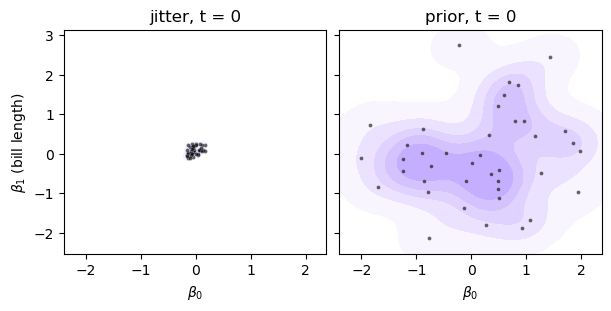

In [5]:
# t = 0 particle clouds in (beta_0, beta_1); shared limits across inits
xlim, ylim = beta_limits([
    record_for(init)["traj"][0][:, :2] for init in INIT_CHOICES
])
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharex=True, sharey=True, layout="constrained")
for ax, init in zip(axes, INIT_CHOICES):
    plot_beta_cloud(
        ax,
        record_for(init)["traj"][0][:, :2],
        xlim,
        ylim,
        f"{init}, t = 0",
    )
plt.show()


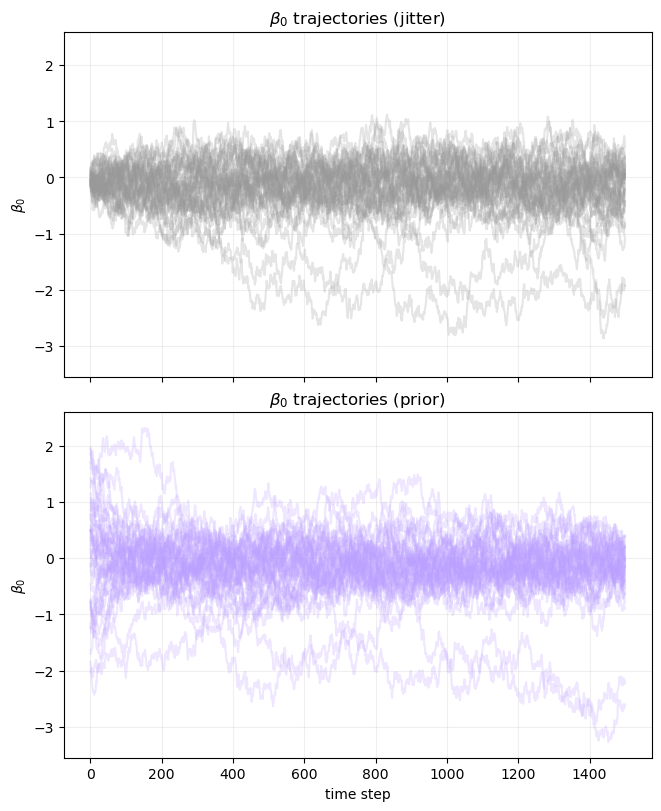

In [6]:
# every particle's beta_0 path (seed=0); faint lines show dispersion
fig, axes = plt.subplots(
    2, 1, figsize=(FIGSIZE[0], 2 * FIGSIZE[1]), sharex=True, sharey=True, layout="constrained"
)
for ax, init in zip(axes, INIT_CHOICES):
    traj = record_for(init)["traj"]
    steps = np.arange(traj.shape[0])
    for j in range(traj.shape[1]):
        ax.plot(steps, traj[:, j, 0], color=INIT_COLORS[init], alpha=0.25)
    ax.set(title=rf"$\beta_0$ trajectories ({init})", ylabel=r"$\beta_0$")
    ax.grid(alpha=0.2)
axes[-1].set_xlabel("time step")
plt.show()


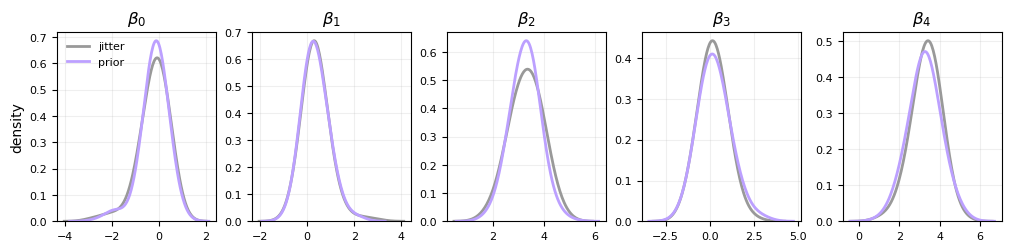

In [7]:
# 1D marginals of final beta components; pooled over seeds per init
fig, axes = plt.subplots(1, 5, figsize=(10, 2.4), layout="constrained")
for dim, (ax, xlab) in enumerate(zip(axes, BETA_LABELS)):
    for init in INIT_CHOICES:
        sns.kdeplot(
            x=finals_for(init)[:, dim],
            ax=ax,
            color=INIT_COLORS[init],
            linewidth=2,
            bw_adjust=BW_ADJUST_1D,
            label=init,
        )
    ax.set(title=xlab, xlabel="", ylabel="density" if dim == 0 else "")
    ax.grid(alpha=0.2)
    ax.tick_params(labelsize=8)
axes[0].legend(frameon=False, fontsize=8)
plt.show()


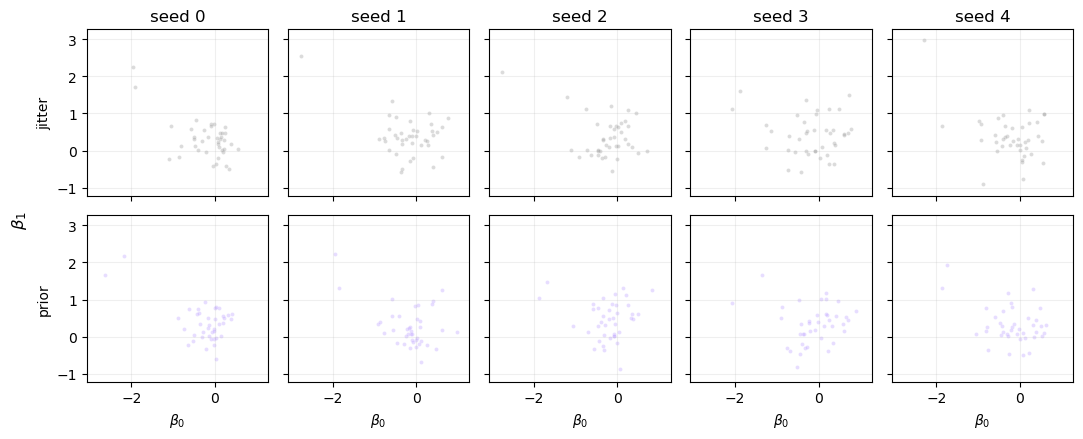

In [8]:
# final (beta_0, beta_1) clouds: rows = init, columns = seed
fig, axes = plt.subplots(2, len(SEEDS), figsize=(2.2 * len(SEEDS), 4.5), sharex=True, sharey=True)
all_pts = np.vstack([
    record_for(init, seed=seed)["final"][:, :2]
    for init in INIT_CHOICES
    for seed in SEEDS
])
xlim, ylim = beta_limits([all_pts], pad=0.3)
for row, init in enumerate(INIT_CHOICES):
    for col, seed in enumerate(SEEDS):
        ax = axes[row, col]
        pts = record_for(init, seed=seed)["final"][:, :2]
        sns.scatterplot(
            x=pts[:, 0],
            y=pts[:, 1],
            s=8,
            alpha=0.35,
            color=INIT_COLORS[init],
            legend=False,
            ax=ax,
        )
        ax.set(xlim=xlim, ylim=ylim)
        if row == 0:
            ax.set_title(f"seed {seed}")
        if col == 0:
            ax.set_ylabel(init)
        if row == 1:
            ax.set_xlabel(r"$\beta_0$")
        ax.grid(alpha=0.2)
fig.supylabel(r"$\beta_1$", x=0.02)
plt.tight_layout()
plt.show()


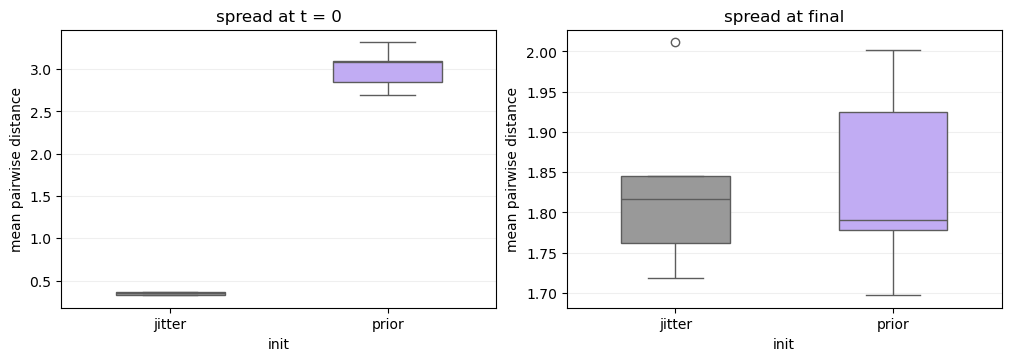

In [9]:
# spread summary: mean pairwise distance at t=0 vs after n_steps
plot_df = summary.copy()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout="constrained")
for ax, metric, title in zip(
    axes,
    ["t0_spread", "final_spread"],
    ["spread at t = 0", "spread at final"],
):
    sns.boxplot(
        data=plot_df,
        x="init",
        y=metric,
        hue="init",
        palette=INIT_COLORS,
        legend=False,
        width=0.5,
        ax=ax,
    )
    ax.set(title=title, xlabel="init", ylabel="mean pairwise distance")
    ax.grid(alpha=0.2, axis="y")
plt.show()


## Hold-out predictive (test fold)

No extra sampling: reuse train-fit particles at `seed=HOLDOUT_SEED` and score them on the 25% test set.

- **Outcome check:** Bernoulli posterior predictive histogram vs test sex labels.
- **Covariate slices:** particle-mixture $P(\mathrm{male} \mid x)$ on each 2D covariate face (other covariates fixed at test-set means).


In [10]:
COV_SLICES = list(combinations(range(len(cols)), 2))


def _sigmoid(logits):
    out = np.empty_like(logits, dtype=np.float64)
    pos = logits >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-logits[pos]))
    x = logits[~pos]
    exp_x = np.exp(x)
    out[~pos] = exp_x / (1.0 + exp_x)
    return out


def mixture_predictive_probs(particles, X):
    """Particle-mixture P(y=1 | x) for logistic coefficients."""
    logits = particles[:, 0] + X @ particles[:, 1:].T
    return _sigmoid(logits).mean(axis=1)


def eval_holdout(particles, X_test, y_test):
    p = np.clip(mixture_predictive_probs(particles, X_test), 1e-15, 1 - 1e-15)
    log_pred = np.where(y_test == 1, np.log(p), np.log(1 - p))
    return {
        "n_test": len(y_test),
        "log_score": log_pred.sum(),
        "mean_log_score": log_pred.mean(),
        "accuracy": ((p >= 0.5) == y_test).mean(),
        "brier": ((p - y_test) ** 2).mean(),
    }


def posterior_predictive_bernoulli(particles, X, rng, n_rep=None):
    """y_rep ~ Bern(sigmoid(logit_k(x))) with k ~ Uniform over particles."""
    n_obs, n_particles = len(X), len(particles)
    if n_rep is None:
        n_rep = max(1, n_obs // n_particles)
    logits = particles[:, 0] + X @ particles[:, 1:].T
    draws = []
    for _ in range(n_rep):
        k = rng.integers(0, n_particles, size=n_obs)
        p = _sigmoid(logits[np.arange(n_obs), k])
        draws.append(rng.binomial(1, p))
    return np.concatenate(draws)


def _slice_pad(vals):
    span = vals.max() - vals.min()
    return max(PAD_2D, 0.05 * span)


def build_slice_grid(i, j, test_df, slice_means, transform):
    """Build a 2D grid; fix non-slice covariates at test-set means."""
    xi = test_df[cols[i]].values
    xj = test_df[cols[j]].values
    xlim = (xi.min() - _slice_pad(xi), xi.max() + _slice_pad(xi))
    ylim = (xj.min() - _slice_pad(xj), xj.max() + _slice_pad(xj))
    xx, yy = np.meshgrid(
        np.linspace(*xlim, 100),
        np.linspace(*ylim, 100),
    )
    raw = np.zeros((xx.size, len(cols)))
    for k, col in enumerate(cols):
        if k == i:
            raw[:, k] = xx.ravel()
        elif k == j:
            raw[:, k] = yy.ravel()
        else:
            raw[:, k] = slice_means[col]
    return xx, yy, xlim, ylim, transform(raw), xi, xj


# reuse train-fit particles at HOLDOUT_SEED — no second sample_pro pass
holdout_results = {}
for init in INIT_CHOICES:
    finals = record_for(init, seed=HOLDOUT_SEED)["final"]
    holdout_results[init] = {"finals": finals, **eval_holdout(finals, X_test, y_test)}

holdout_df = pd.DataFrame(
    [
        {"init": init, **{k: v for k, v in res.items() if k != "finals"}}
        for init, res in holdout_results.items()
    ]
)
holdout_df


,init,n_test,log_score,mean_log_score,accuracy,brier
0,jitter,84,-29.500986,-0.351202,0.821429,0.112085
1,prior,84,-30.133180,-0.358728,0.821429,0.115519


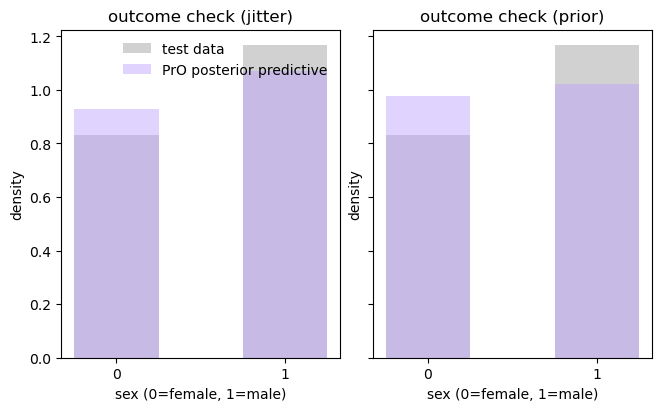

In [11]:
# posterior predictive sex distribution vs held-out test labels
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE, sharey=True, layout="constrained")
sex_bins = [-0.25, 0.25, 0.75, 1.25]
for ax, init in zip(axes, INIT_CHOICES):
    finals = holdout_results[init]["finals"]
    rng_pp = np.random.default_rng(HOLDOUT_SEED + 1)
    y_pp = posterior_predictive_bernoulli(finals, X_test, rng_pp)
    ax.hist(y_test, bins=sex_bins, density=True, alpha=0.45, color=COLOR_DATA, label="test data")
    ax.hist(
        y_pp,
        bins=sex_bins,
        density=True,
        alpha=0.45,
        color=COLOR_PRO,
        label="PrO posterior predictive",
    )
    ax.set(
        title=f"outcome check ({init})",
        xlabel="sex (0=female, 1=male)",
        ylabel="density",
        xticks=[0, 1],
    )
axes[0].legend(frameon=False)
plt.show()


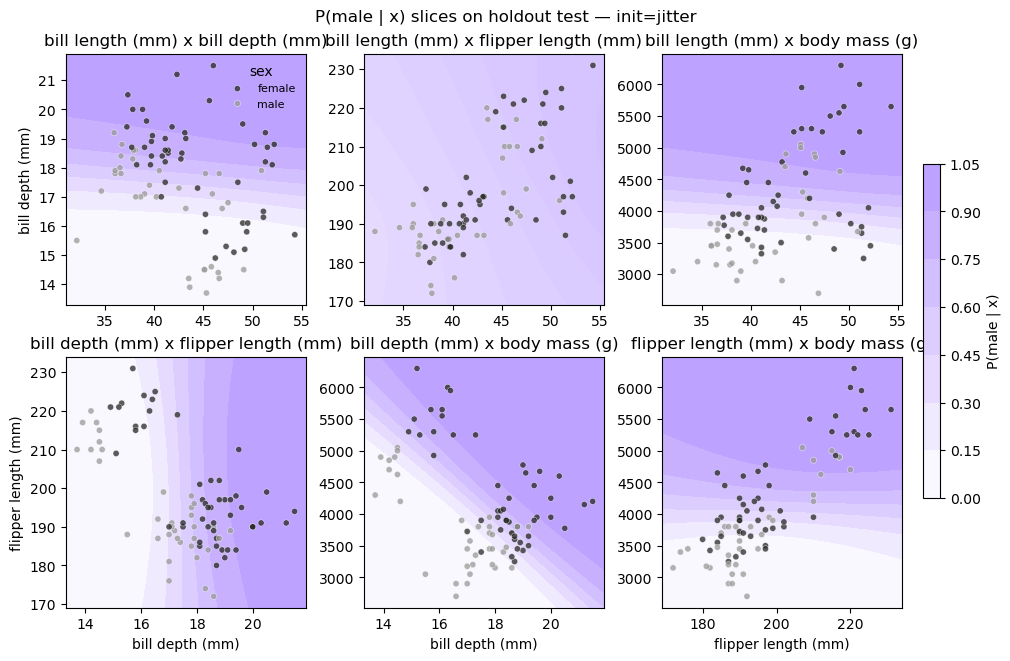

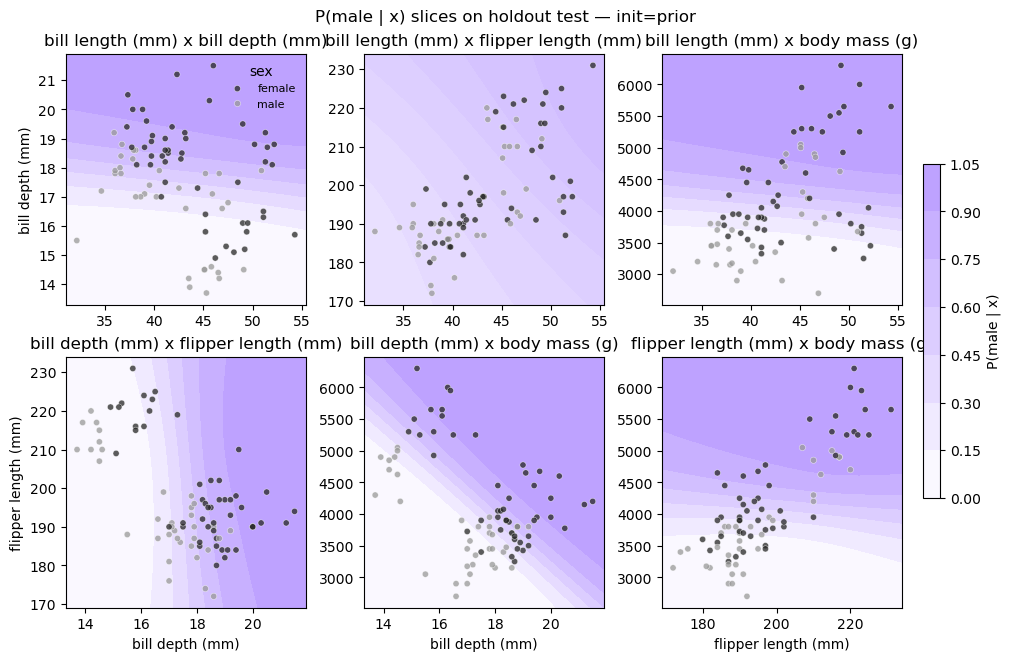

In [12]:
test_df = df.iloc[test_idx]
slice_means = test_df[cols].mean().to_dict()

for init in INIT_CHOICES:
    finals = holdout_results[init]["finals"]
    fig, axes = plt.subplots(2, 3, figsize=(10, 6.5), layout="constrained")
    cf = None
    for col, (i, j) in enumerate(COV_SLICES):
        row, c = divmod(col, 3)
        ax = axes[row, c]
        xx, yy, xlim, ylim, X_grid, xi, xj = build_slice_grid(
            i, j, test_df, slice_means, scaler.transform
        )
        # map raw mm/g grid points into the model's scaled covariate space
        zz = mixture_predictive_probs(finals, X_grid).reshape(xx.shape)
        cf = ax.contourf(xx, yy, zz, levels=N_LEVELS, cmap=PRO_CMAP, vmin=0, vmax=1)
        sns.scatterplot(
            x=xi,
            y=xj,
            hue=y_test,
            palette=SEX_PALETTE,
            hue_order=[0, 1],
            alpha=0.75,
            s=20,
            legend=col == 0,
            ax=ax,
        )
        ax.set(
            title=f"{COL_LABELS[cols[i]]} x {COL_LABELS[cols[j]]}",
            xlabel=COL_LABELS[cols[i]] if row == 1 else "",
            ylabel=COL_LABELS[cols[j]] if c == 0 else "",
            xlim=xlim,
            ylim=ylim,
        )
    if axes[0, 0].legend_ is not None:
        axes[0, 0].legend(title="sex", labels=["female", "male"], frameon=False, fontsize=8)
    fig.suptitle(f"P(male | x) slices on holdout test — init={init}")
    fig.colorbar(cf, ax=axes, fraction=0.02, pad=0.02, label="P(male | x)")
    plt.show()
